### YOLO pose estimation

This notebook verifies that the YOLO pose model is working correctly on sample images.

The goal of this smoke test is to:

- Ensure the model loads successfully
- Run inference on a test image
- Visualize detected persons and keypoints
- Inspect bounding boxes, confidence scores, and pose outputs


### Notebooks config and imports 

In [1]:
from __future__ import annotations

import time 
from pathlib import Path

import torch 
from ultralytics import YOLO 

import numpy as np

from src.constants import IMAGES_DIR
from src.logger.custom_logger import configure_logger,logger
from src.utils.io import ImageLoader

10:54:03 | INFO     | src.logger.custom_logger:configure_logger:59 | Logger configured — log file: C:\Users\rsurs\OneDrive\Documents\cynapse-ai-assignment\logs\2026-05-10\10-54-03.log


In [2]:
configure_logger(log_level="INFO")

10:54:03 | INFO     | src.logger.custom_logger:configure_logger:59 | Logger configured — log file: C:\Users\rsurs\OneDrive\Documents\cynapse-ai-assignment\logs\2026-05-10\10-54-03.log


WindowsPath('C:/Users/rsurs/OneDrive/Documents/cynapse-ai-assignment/logs/2026-05-10/10-54-03.log')

### Loading the model 

In [3]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_NAME = "yolo11m-pose.pt"
loader = ImageLoader()

In [4]:
logger.info(f"Loading {MODEL_NAME} in {DEVICE}")

t0 = time.perf_counter()

pose_model = YOLO(MODEL_NAME)
pose_model.to(DEVICE)
load_ms = (time.perf_counter() - t0) * 1000 
logger.info(f"Pose model loaded in {load_ms:}.0f ms")
print(f"Model classes:{pose_model.names}")

10:54:05 | INFO     | __main__:<module>:1 | Loading yolo11m-pose.pt in cuda
10:54:06 | INFO     | __main__:<module>:8 | Pose model loaded in 764.179400051944.0f ms
Model classes:{0: 'person'}


### Examining `pose_model` output

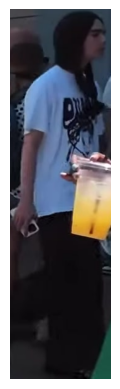

In [5]:
import matplotlib.pyplot as plt 
import cv2 

sample_path = IMAGES_DIR / "crop (33).png"
img = cv2.imread(str(sample_path))
img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis('off')
plt.show()


In [6]:
t0 = time.perf_counter()
crop = loader.load(sample_path)
print(f"Crop {crop.crop_id} image shape: {crop.image.shape}")

t0 = time.perf_counter() 
# cold inference (first call GPU warmup)
results = pose_model(crop.image,
                     conf=0.25,
                     verbose=False)

cold_ms = (time.perf_counter() - t0) * 1000 

t0 = time.perf_counter()
results = pose_model(crop.image,
                     conf=0.25,
                     verbose=False)
# warm inference for true steady timing 
warm_ms = (time.perf_counter() - t0) * 1000
logger.info(f"cold inference: {cold_ms:.0f} warm inference: {warm_ms:.0f}")

result = results[0]
print(f"result type: {type(result)}")
print(f"number of detections: {len(result.boxes)}")
print(f"has keypoint detections: {hasattr(result,"keypoints")}")
print(f"type of result keypoints: {type(result.keypoints)}")

10:54:06 | INFO     | src.utils.io:load:61 | Loaded crop (33).png | shape: ((163, 600, 3)) | bytes: 293400
Crop crop (33) image shape: (600, 163, 3)
10:54:07 | INFO     | __main__:<module>:19 | cold inference: 686 warm inference: 13
result type: <class 'ultralytics.engine.results.Results'>
number of detections: 2
has keypoint detections: True
type of result keypoints: <class 'ultralytics.engine.results.Keypoints'>


### Examining keypoint structure

In [7]:
kpts = result.keypoints

print(f"data shape:{kpts.shape}") # data: (x,y,conf) per keypoint, shape:(n_persons,17,3)
print(f"xy shape:{kpts.xy.shape}") # xy: (x,y) shape: (n_persons,17,2)
print(f"xyn shape:{kpts.xyn.shape}") # normalized (x,y) shape: (n_persons,17,2) - [0,1]
print(f"conf shape:{kpts.conf.shape if kpts.conf is not None else 'None'}") # conf per keypoint,shape: (n_persons,17)

# pull the first detected person keypoint to cpu
person_0_data = kpts.data[0].cpu().numpy()
person_0_xyn = kpts.xyn[0].cpu().numpy()
person_0_conf = kpts.conf[0].cpu().numpy()

print("keypoints for person 0:")
print("idx |   x_pix   y_pix   conf  | x_norm   y_norm")
for i in range(17):
    x_p, y_p, c = person_0_data[i]
    x_n, y_n = person_0_xyn[i]
    print(f"{i:>3} | {x_p:>7.1f} {y_p:>7.1f} {c:>5.2f}  | {x_n:>6.3f}  {y_n:>6.3f}")

print(f"\nCrop dimensions for sanity-check: H={crop.height}, W={crop.width}")


data shape:torch.Size([2, 17, 3])
xy shape:torch.Size([2, 17, 2])
xyn shape:torch.Size([2, 17, 2])
conf shape:torch.Size([2, 17])
keypoints for person 0:
idx |   x_pix   y_pix   conf  | x_norm   y_norm
  0 |   148.0    48.6  0.88  |  0.908   0.081
  1 |   148.3    38.2  0.27  |  0.910   0.064
  2 |   136.8    38.5  0.94  |  0.840   0.064
  3 |   129.0    45.0  0.06  |  0.791   0.075
  4 |   104.6    47.6  0.97  |  0.642   0.079
  5 |   126.6   122.6  0.78  |  0.777   0.204
  6 |    67.9   124.7  0.99  |  0.417   0.208
  7 |   131.4   215.4  0.25  |  0.806   0.359
  8 |    34.4   223.1  0.98  |  0.211   0.372
  9 |   142.5   262.8  0.23  |  0.874   0.438
 10 |    22.7   316.9  0.95  |  0.139   0.528
 11 |   116.2   311.7  0.95  |  0.713   0.519
 12 |    80.9   315.5  0.99  |  0.496   0.526
 13 |   114.3   457.1  0.90  |  0.701   0.762
 14 |    93.9   460.2  0.97  |  0.576   0.767
 15 |   100.6   568.4  0.48  |  0.617   0.947
 16 |    93.8   582.3  0.66  |  0.576   0.970

Crop dimensions

In [8]:
COCO_KEYPOINTS = ["nose",
                  "left_eye",
                  "right_eye",
                  'left_ear',
                  'right_ear',
                  'left_shoulder',
                  'right_shoulder',
                  "left_elbow",
                  "right_elbow",
                  "left_wrist",
                  "right_wrist",
                  "left_hip",
                  "right_hip",
                  "left_knee",
                  "right_knee",
                  "left_ankle",
                  "right_ankle"]

print(f"{'idx':>3}  {'name':<16}  {'x_norm':>7}  {'y_norm':>7}  {'conf':>5}")
print("-" * 50)
for i,name in enumerate(COCO_KEYPOINTS):
    x_n,y_n = person_0_xyn[i]
    c = person_0_conf[i]
    visibility = "visible" if c >= 0.5 else "not visible"
    print(f"{i:>3}  {name:<16}  {x_n:>7.3f}  {y_n:>7.3f}  {c:>5.2f}  {visibility}")


idx  name               x_norm   y_norm   conf
--------------------------------------------------
  0  nose                0.908    0.081   0.88  visible
  1  left_eye            0.910    0.064   0.27  not visible
  2  right_eye           0.840    0.064   0.94  visible
  3  left_ear            0.791    0.075   0.06  not visible
  4  right_ear           0.642    0.079   0.97  visible
  5  left_shoulder       0.777    0.204   0.78  visible
  6  right_shoulder      0.417    0.208   0.99  visible
  7  left_elbow          0.806    0.359   0.25  not visible
  8  right_elbow         0.211    0.372   0.98  visible
  9  left_wrist          0.874    0.438   0.23  not visible
 10  right_wrist         0.139    0.528   0.95  visible
 11  left_hip            0.713    0.519   0.95  visible
 12  right_hip           0.496    0.526   0.99  visible
 13  left_knee           0.701    0.762   0.90  visible
 14  right_knee          0.576    0.767   0.97  visible
 15  left_ankle          0.617    0.947   0.48

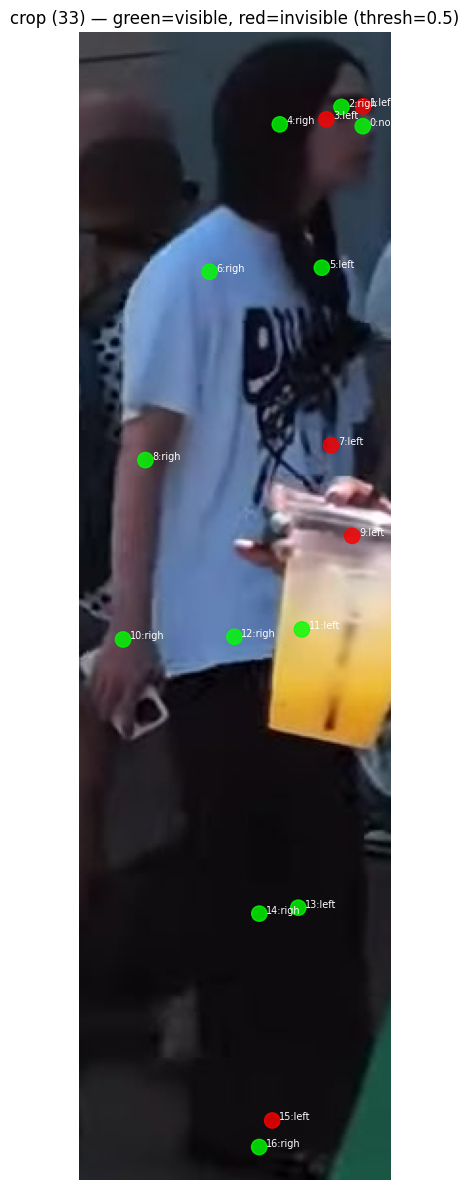

Visible keypoints: 12 / 17


In [9]:
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

fig, ax = plt.subplots(figsize=(8, 12))
ax.imshow(crop.image)

KEYPOINT_THRESHOLD = 0.5  # matches your YAML's keypoint_confidence

for i, name in enumerate(COCO_KEYPOINTS):
    x_p, y_p = person_0_data[i, :2]
    c = person_0_conf[i]
    color = "lime" if c >= KEYPOINT_THRESHOLD else "red"
    ax.add_patch(Circle((x_p, y_p), radius=4, color=color, alpha=0.8))
    ax.annotate(
        f"{i}:{name[:4]}",
        (x_p, y_p),
        fontsize=7,
        color="white",
        xytext=(5, 0),
        textcoords="offset points",
    )

ax.set_title(f"{crop.crop_id} — green=visible, red=invisible (thresh={KEYPOINT_THRESHOLD})")
ax.axis("off")
plt.tight_layout()
plt.show()

print(f"Visible keypoints: {(person_0_conf >= KEYPOINT_THRESHOLD).sum()} / 17")

### Stage 2 Diagnostic — Investigating the 57% Pose Rejection

Stage 2 rejects 319 of 557 detection-survivors (57%). Two hypotheses:

- **H1 — dataset is genuinely half-body.** Many crops are torso-up, face-only, or otherwise partial-body. Stage 2 correctly filters them.
- **H2 — thresholds are too strict.** `min_leg_kpts: 4` (both knees + both ankles) is stringent. Even visibly full-body people may lose one keypoint to confidence near 0.5.

This notebook eyeballs rejected crops and looks at metric distributions to decide.

In [ ]:
from __future__ import annotations 
from pathlib import Path 
import hashlib

import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 

from src.components.person_detector import PersonDetector
from src.components.pose_filter import PoseFilter
from src.components.quality_filter import QualityFilter

from src.settings.config import (PersonDetectionThresholds,
                                 PoseThresholds,
                                 QualityThresholds)
from src.utils.io import ImageLoader

from src.constants import IMAGES_DIR

In [11]:
configure_logger(log_level="WARNING")

WindowsPath('C:/Users/rsurs/OneDrive/Documents/cynapse-ai-assignment/logs/2026-05-10/10-57-37.log')

In [12]:
quality_filter = QualityFilter(QualityThresholds())
detector = PersonDetector(PersonDetectionThresholds())
pose = PoseFilter(PoseThresholds())
loader =  ImageLoader()

In [13]:
def file_hash(path: Path) -> str:
    return hashlib.md5(path.read_bytes()).hexdigest()

all_paths = sorted(IMAGES_DIR.glob("*.png"))
seen_hashes: set[str] = set()
unique_paths: list[Path] = []

for p in all_paths:
    h = file_hash(p)
    
    if h in seen_hashes:
        continue 

    seen_hashes.add(h)
    unique_paths.append(p)

print(f"Unique images: {len(unique_paths)}")

Unique images: 1001


In [15]:
records: list[dict] = []

for path in unique_paths:
    crop = loader.load(path)

    quality_result = quality_filter.apply(crop)

    if not quality_result.passed:
        records.append({"crop_id":crop.crop_id,
                        "source_path":str(path),
                        "stage_reached":"quality",
                        "passed_quality":False,
                        "passed_detection":None,
                        "passed_pose":None,
                        "n_head_visible":np.nan,
                        "n_torso_visible":np.nan,
                        "n_leg_visible":np.nan,
                        "n_visible_keypoints":np.nan,
                        "pose_reason":None})
        continue

    detection_result = detector.apply(crop)
    if not detection_result.passed:
        records.append({"crop_id":crop.crop_id,
                        "source_path":str(path),
                        "stage_reached":"detection",
                        "passed_quality":True,
                        "passed_detection":False,
                        "passed_pose":None,
                        "n_head_visible":np.nan,
                        "n_torso_visible":np.nan,
                        "n_leg_visible":np.nan,
                        "n_visible_keypoints":np.nan,
                        "pose_reason":None})
        continue 

    pose_result = pose.apply(crop)
    records.append({"crop_id":crop.crop_id,
                    "source_path":str(path),
                    "stage_reached":"pose",
                    "passed_quality":True,
                    "passed_detection":True,
                    "passed_pose":pose_result.passed,
                    "n_head_visible": pose_result.metrics.get("n_head_visible"),
                    "n_torso_visible": pose_result.metrics.get("n_torso_visible"),
                    "n_leg_visible": pose_result.metrics.get("n_leg_visible"),
                    "n_visible_keypoints": pose_result.metrics.get("n_visible_keypoints"),
                    "pose_reason": pose_result.reason})
    
df = pd.DataFrame.from_records(records)
print(f"Records:{len(df)}")
print("df shape:",df.shape)
df.head()

Records:1001
df shape: (1001, 11)


,crop_id,source_path,stage_reached,passed_quality,passed_detection,passed_pose,n_head_visible,n_torso_visible,n_leg_visible,n_visible_keypoints,pose_reason
0,crop (1),C:\Users\rsurs\OneDrive\Documents\cynapse-ai-a...,pose,True,True,False,2.0,4.0,2.0,9.0,legs=2 < 4
1,crop (10),C:\Users\rsurs\OneDrive\Documents\cynapse-ai-a...,quality,False,None,None,NaN,NaN,NaN,NaN,None
2,crop (100),C:\Users\rsurs\OneDrive\Documents\cynapse-ai-a...,detection,True,False,None,NaN,NaN,NaN,NaN,None
3,crop (1000),C:\Users\rsurs\OneDrive\Documents\cynapse-ai-a...,pose,True,True,False,0.0,0.0,0.0,0.0,head=0 < 1 | torso=0 < 4 | legs=0 < 4
4,crop (1001),C:\Users\rsurs\OneDrive\Documents\cynapse-ai-a...,detection,True,False,None,NaN,NaN,NaN,NaN,None


### Examining the results that passed and failed

In [17]:
pose_evaluated = df[df['stage_reached'] == "pose"].copy()
print(f"Images that passed until Stage 2: {len(pose_evaluated)}")

num_passed = (pose_evaluated["passed_pose"] == True).sum()
num_failed = (pose_evaluated["passed_pose"] == False).sum()

print("No of images that passed pose detection:",num_passed)
print("No of images that failed pose detection:",num_failed)

print("Examining the pose failure rejection reasons")
fail_reasons = (pose_evaluated[pose_evaluated['passed_pose'] == False]['pose_reason']).value_counts()
print(fail_reasons)

Images that passed until Stage 2: 461
No of images that passed pose detection: 208
No of images that failed pose detection: 253
Examining the pose failure rejection reasons
pose_reason
legs=2 < 4                               44
head=0 < 1 | torso=0 < 4 | legs=0 < 4    41
legs=0 < 4                               32
head=0 < 1                               15
no_pose_detected                         13
torso=2 < 4 | legs=0 < 4                 13
legs=3 < 4                               10
head=0 < 1 | torso=1 < 4 | legs=0 < 4    10
torso=1 < 4 | legs=0 < 4                 10
head=0 < 1 | torso=2 < 4 | legs=0 < 4     8
head=0 < 1 | torso=3 < 4                  7
head=0 < 1 | legs=2 < 4                   7
torso=0 < 4 | legs=0 < 4                  6
head=0 < 1 | torso=2 < 4                  5
legs=1 < 4                                4
head=0 < 1 | torso=2 < 4 | legs=1 < 4     4
torso=3 < 4 | legs=0 < 4                  4
head=0 < 1 | legs=0 < 4                   3
head=0 < 1 | torso=3 < 

### Distribution of visible keypoints per group

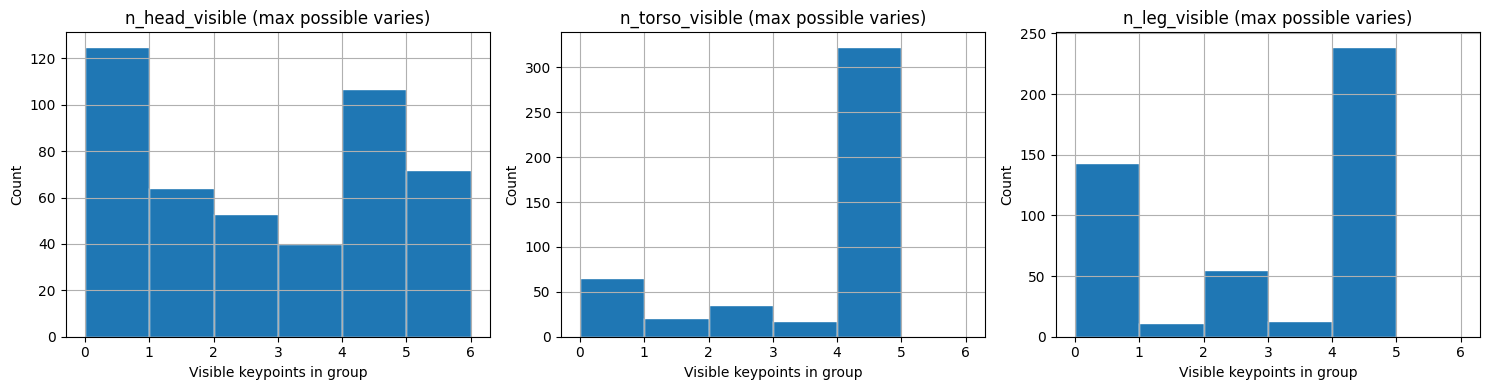

Distribution of n_leg_visible (max=4)
n_leg_visible
0.0    143
1.0     11
2.0     55
3.0     13
4.0    239
Name: count, dtype: int64


In [18]:
fig,axes = plt.subplots(1,3,figsize=(15,4))

for ax,group in zip(axes,["n_head_visible","n_torso_visible","n_leg_visible"]):
    pose_evaluated[group].hist(bins=range(7),ax=ax,edgecolor="white")
    ax.set_title(f"{group} (max possible varies)")
    ax.set_xlabel("Visible keypoints in group")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

print("Distribution of n_leg_visible (max=4)")
print(pose_evaluated["n_leg_visible"].value_counts().sort_index())

### Visually Examining rejected images 

In [19]:
rejected = pose_evaluated[pose_evaluated['passed_pose'] == False]
display(rejected.head())
print("rejected pose df shape:",rejected.shape)

,crop_id,source_path,stage_reached,passed_quality,passed_detection,passed_pose,n_head_visible,n_torso_visible,n_leg_visible,n_visible_keypoints,pose_reason
0,crop (1),C:\Users\rsurs\OneDrive\Documents\cynapse-ai-a...,pose,True,True,False,2.0,4.0,2.0,9.0,legs=2 < 4
3,crop (1000),C:\Users\rsurs\OneDrive\Documents\cynapse-ai-a...,pose,True,True,False,0.0,0.0,0.0,0.0,head=0 < 1 | torso=0 < 4 | legs=0 < 4
6,crop (1003),C:\Users\rsurs\OneDrive\Documents\cynapse-ai-a...,pose,True,True,False,3.0,4.0,0.0,9.0,legs=0 < 4
7,crop (1004),C:\Users\rsurs\OneDrive\Documents\cynapse-ai-a...,pose,True,True,False,0.0,4.0,4.0,10.0,head=0 < 1
10,crop (1007),C:\Users\rsurs\OneDrive\Documents\cynapse-ai-a...,pose,True,True,False,4.0,0.0,0.0,4.0,torso=0 < 4 | legs=0 < 4


rejected pose df shape: (253, 11)


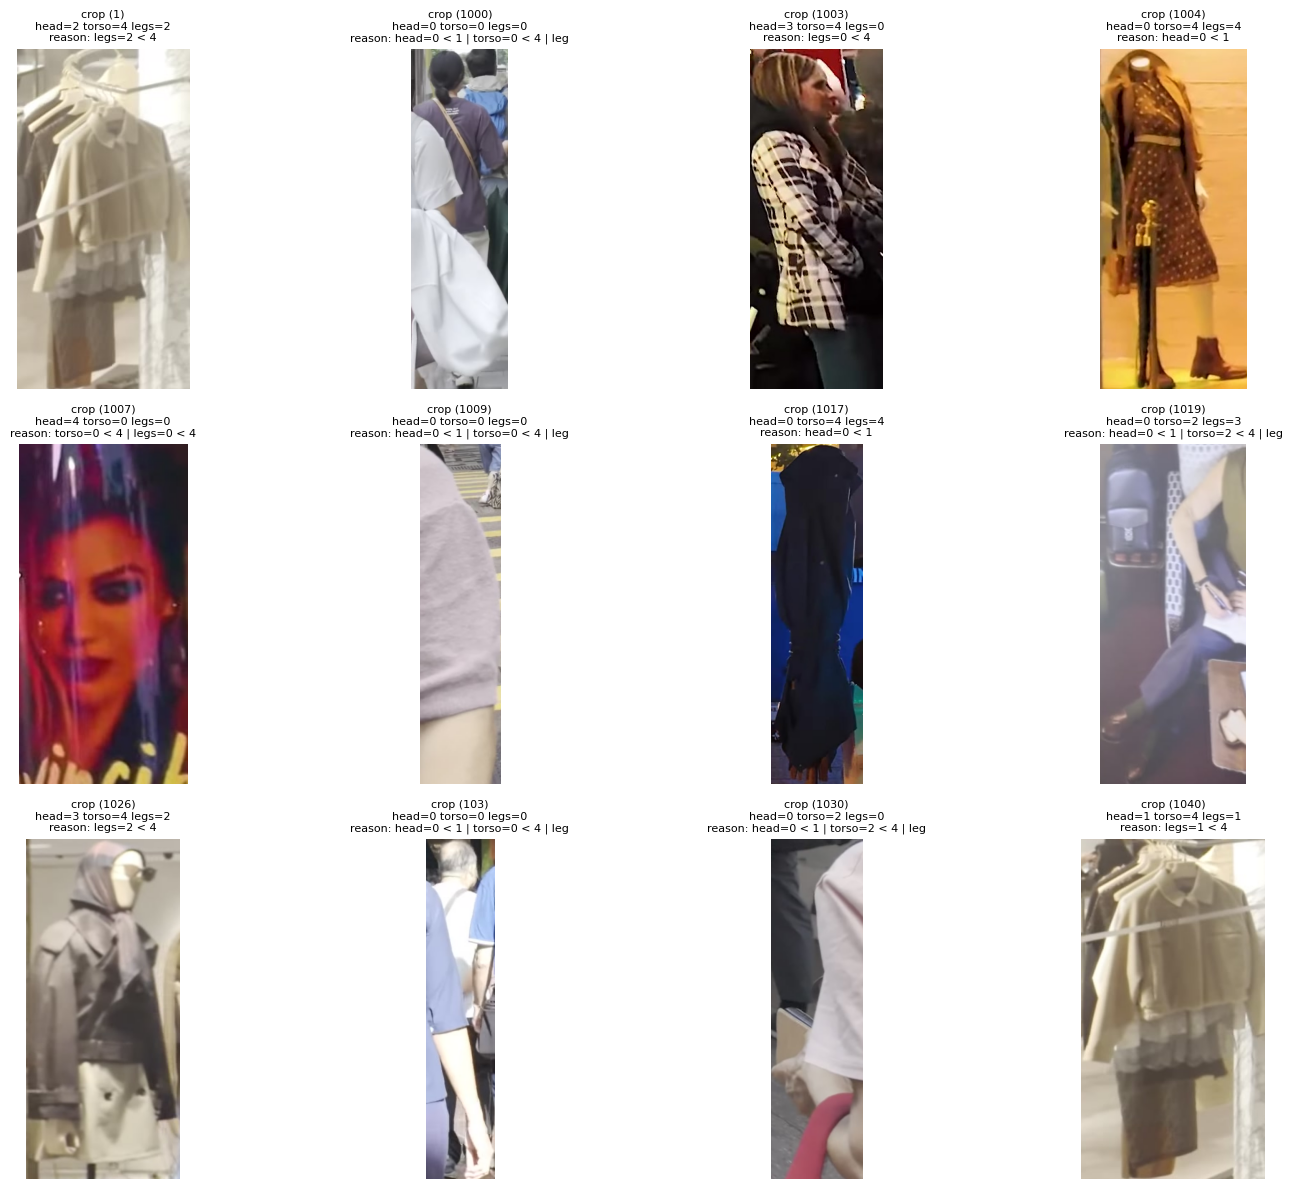

In [20]:
n_rows,n_cols = 3,4 
fig,axes = plt.subplots(n_rows,n_cols,figsize=(16,4*n_rows))
axes = axes.flatten()

for ax,(_,row) in zip(axes,rejected.iterrows()):
    crop = loader.load(Path(row["source_path"]))
    
    ax.imshow(crop.image)
    ax.set_title(f"{row["crop_id"][:18]}\n"
                 f"head={int(row["n_head_visible"])} "
                 f"torso={int(row["n_torso_visible"])} "
                 f"legs={int(row["n_leg_visible"])}\n"
                 f"reason: {row["pose_reason"][:30]}",
                 fontsize=8)
    ax.axis("off")

for ax in axes[len(rejected):]:
    ax.axis("off")

plt.tight_layout()
plt.show()


### Rejected 12 images 

- The rejected images are manequins, only clothes, adverts, partial crops of humans doesnt cover the full body 

#### Threshold sensitivity sweep

In [21]:
print("Sensitivity sweep on min_leg_kpts (curr = 4)")
print(f"{'min_leg_kpts':>14}  {'pose_pass':>10}  {'rate':>6}")
for thresh in [4, 3, 2, 1, 0]:
    head_ok = pose_evaluated["n_head_visible"] >= 1
    torso_ok = pose_evaluated["n_torso_visible"] >= 4
    legs_ok = pose_evaluated["n_leg_visible"] >= thresh
    would_pass = head_ok & torso_ok & legs_ok
    n_pass = would_pass.sum()
    print(f"{thresh:>14}  {n_pass:>10}  {n_pass/len(pose_evaluated)*100:>5.1f}%")


Sensitivity sweep on min_leg_kpts (curr = 4)
  min_leg_kpts   pose_pass    rate
             4         208   45.1%
             3         218   47.3%
             2         262   56.8%
             1         266   57.7%
             0         298   64.6%


### Conclusion: Stage 2 rejection is mostly justified

- The diagnostic supports **H1 more than H2**: many rejected crops are genuinely not full-body, including mannequins, clothing/ad images, and partial human crops.

- The threshold sweep shows `min_leg_kpts` is not the main issue. Relaxing it from `4` to `3` only increases pose-pass crops from `208` to `218`, so few rejected crops are borderline full-body cases.

- Final evaluation supports keeping Stage 2 as-is: `not_full_body` reaches **97.96% coverage** (`48/49` rejected), which matches the goal of filtering incomplete body crops.
